In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# TP : Exploration d'un Dataset de Segmentation Sémantique

Ce TP vous permet de vous familiariser avec la structure et le contenu d'un dataset de segmentation sémantique.

La segmentation sémantique consiste à attribuer une classe à chaque pixel d'une image, permettant ainsi une compréhension fine de la scène.

Vous allez manipuler un dataset de scènes urbaines où chaque image est accompagnée d'un masque de segmentation.

Chaque valeur de pixel dans le masque correspond à une classe spécifique (route, bâtiment, véhicule, piéton, etc.).

L'objectif est de comprendre la structure de ces données, de visualiser les masques de segmentation et d'explorer comment les différentes classes sont représentées dans les images.

In [2]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
import numpy as np

### Définir le répertoire des données

Définissez la variable `data_dir` pointant vers le répertoire contenant le dataset de segmentation (`../data/seg-dataset`).

Ce répertoire contient des sous-dossiers pour les ensembles d'entraînement et de test, chacun avec des dossiers `images` et `masks`.

In [18]:
data_dir = "/content/drive/MyDrive/computer_vision/td13/data/seg-dataset"

### Lister les fichiers du dataset d'entraînement

Utilisez `glob` pour créer deux listes :
- `train_image_files` : tous les fichiers PNG d'images dans le dossier `train/images`
- `train_mask_files` : tous les fichiers PNG de masques dans le dossier `train/masks`

Ces listes vous permettront d'accéder facilement aux paires image/masque pour l'exploration du dataset.

In [19]:
train_image_files = glob.glob(f"{data_dir}/train/images/*.png")
train_mask_files = glob.glob(f"{data_dir}/train/masks/*.png")
print(f"Number of training images: {len(train_image_files)}")
print(f"Number of training masks: {len(train_mask_files)}")

Number of training images: 367
Number of training masks: 367


In [26]:
# import zipfile
# voc_dataset_dir = "/content/drive/MyDrive/computer_vision/td13/data"
# zip_path="/content/drive/MyDrive/computer_vision/td13/seg-dataset.zip"
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(voc_dataset_dir)
# os.remove(zip_path)

### Contenu d'un masque de segmentation

Explorer le contenu d'un masque de segmentation : chaque pixel est associé à une classe.

Mask shape: (360, 480)


array([[5, 5, 5, ..., 1, 1, 1],
       [5, 5, 5, ..., 1, 1, 1],
       [5, 5, 5, ..., 1, 1, 1],
       ...,
       [3, 3, 3, ..., 3, 3, 3],
       [3, 3, 3, ..., 3, 3, 3],
       [3, 3, 3, ..., 3, 3, 3]], dtype=uint8)
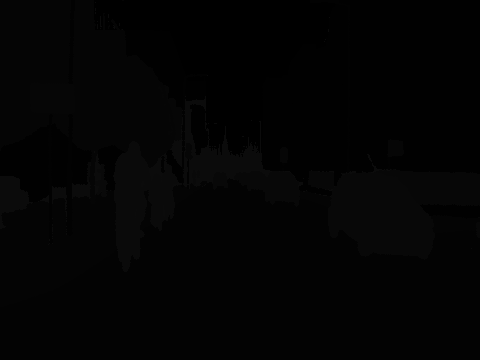

In [21]:
num = 19 # celui là parcequ'il est joli :)
mask_path = train_mask_files[num]
mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
print(f"Mask shape: {mask.shape}")
display(mask)

### Créer une fonction de visualisation côte-à-côte (avec `cv2`)

Implémentez la fonction `plot_image_and_mask(image, mask)` qui affiche une image et son masque de segmentation côte à côte. Cette fonction doit :

- Créer une figure avec deux sous-graphiques disposés horizontalement
- Dans le premier sous-graphique, afficher l'image en couleur
- Dans le second sous-graphique, afficher le masque avec une colormap appropriée pour les classes (`cmap='tab20'`) avec des valeurs allant de 0 à 11
- Ajouter des titres explicites à chaque sous-graphique

In [22]:
def plot_image_and_mask(image, mask):
    """
    Affiche côte à côte une image couleur et son masque de segmentation.

    Paramètres
    ----------
    image : np.ndarray
        Image couleur à afficher.
    mask : np.ndarray
        Masque de segmentation (entiers, valeurs de classe).

    Affiche
    -------
    Une figure matplotlib avec l'image originale et le masque colorisé.
    """
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    axs[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axs[0].set_title('Image')
    axs[0].axis('off')

    axs[1].imshow(mask, cmap='tab20', vmin=0, vmax=11)
    axs[1].set_title('Mask')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

### Créer une fonction d'exploration complète

Implémentez la fonction `show_image_and_mask(image_path, mask_path)` qui charge et affiche une paire image/masque tout en fournissant des informations sur leurs caractéristiques. Cette fonction doit :

- Charger l'image en mode couleur
- Charger le masque en mode `IMREAD_UNCHANGED` pour préserver les valeurs de pixels exactes
- Afficher la forme (shape) de l'image et du masque
- Afficher les valeurs uniques présentes dans le masque (correspondant aux différentes classes)
- Appeler la fonction `plot_image_and_mask` pour visualiser les données

Image shape: (360, 480, 3)
Mask shape: (360, 480)


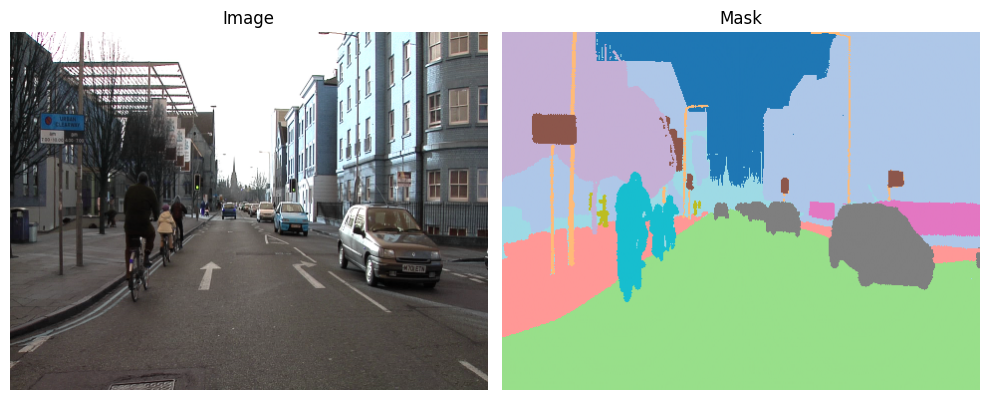

In [24]:
def show_image_and_mask(image_path, mask_path):
    """
    Affiche les informations et la visualisation pour une paire image/masque.

    Paramètres
    ----------
    image_path : str
        Chemin vers l'image couleur.
    mask_path : str
        Chemin vers le masque de segmentation (entiers, valeurs de classe).

    Affiche
    -------
    - La forme de l'image et du masque.
    - Les valeurs uniques présentes dans le masque.
    - Une figure matplotlib avec l'image originale et le masque colorisé.
    """
    img = cv2.cvtColor(cv2.imread(image_path),cv2.COLOR_BGR2RGB)
    print(f"Image shape: {img.shape}")
    img_mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    print(f"Mask shape: {mask.shape}")
    plot_image_and_mask(img,img_mask)


num = 19 # celui là parcequ'il est joli :)
show_image_and_mask(train_image_files[num], train_mask_files[num])

### Définir le mapping des classes

Créez un dictionnaire `CLASS_MAPPING` qui associe chaque identifiant numérique de classe (0 à 11) à son nom sémantique.

Ce mapping vous permettra d'interpréter les valeurs numériques du masque.

In [27]:
CLASS_MAPPING = {
    0: "sky",
    1: "building",
    2: "pole",
    3: "road",
    4: "sidewalk",
    5: "vegetation",
    6: "sign",
    7: "fence",
    8: "vehicle",
    9: "person",
    10: "rider",
    11: "void"
}

### Créer une fonction de superposition par classe

Implémentez la fonction `overlay_mask_on_image(image_path, mask_path, class_id, alpha=0.5, color=(0, 255, 0))` qui permet de visualiser une classe spécifique en la superposant sur l'image originale. Cette fonction doit :

- Charger l'image et le masque depuis leurs chemins respectifs
- Créer un masque binaire `mask_class` en sélectionnant uniquement les pixels correspondant à `class_id` (utiliser une comparaison simple : `mask == class_id`)
- Créer une image de superposition (`overlay`) où les pixels de la classe sont colorés avec la couleur spécifiée
- Fusionner l'image originale et la superposition avec `cv2.addWeighted` en utilisant le paramètre `alpha` pour contrôler la transparence
- Afficher le résultat avec un titre indiquant l'ID et le nom de la classe (utiliser `CLASS_MAPPING`)

In [46]:
def overlay_mask_on_image(image_path, mask_path, class_id, alpha=0.5, color=(0, 255, 0)):
    """
    Superpose le mask correspondant à class_id sur l'image.
    - image_path: chemin de l'image
    - mask_path: chemin du mask
    - class_id: id de la classe à superposer
    - alpha: transparence de la superposition
    - color: couleur de superposition (B, G, R)
    """
    image = cv2.imread(image_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    mask_class = (mask == class_id)

    overlay = image.copy()
    overlay[mask_class] = color

    blended = cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0)

    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
    plt.title(f"Class {class_id} : '{CLASS_MAPPING[class_id]}'")
    plt.axis('off')
    plt.show()


# Parcours tous les id de classes et affiche la superposition pour chacune
for class_id in CLASS_MAPPING.keys():
    overlay_mask_on_image(train_image_files[num], train_mask_files[num], class_id=class_id)

Output hidden; open in https://colab.research.google.com to view.

### Vous pouvez explorer d'autres images...